<a href="https://colab.research.google.com/github/JohnJomi/AIAirQualityTest-/blob/main/AirQualityTest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Download complete.
Raw shape: (9471, 17)
Shape after dropping junk columns/rows: (9357, 15)
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Missing value percentage per column:
 NMHC(GT)         90.231912
CO(GT)           17.986534
NO2(GT)          17.548360
NOx(GT)          17.516298
PT08.S2(NMHC)     3.911510
C6H6(GT)          3.911510
PT08.S1(CO)       3.911510
PT08.S5(O3)       3.911510
T                 3.911510
PT08.S3(NOx)      3.911510
PT08.S4(NO2)      3.911510
RH                3.911510
AH                3.911510
Date              0.000000
Time              0.000000
dtype: float64
(9357, 15)
<class 'pandas.core.frame.DataFrame'>
Index: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   

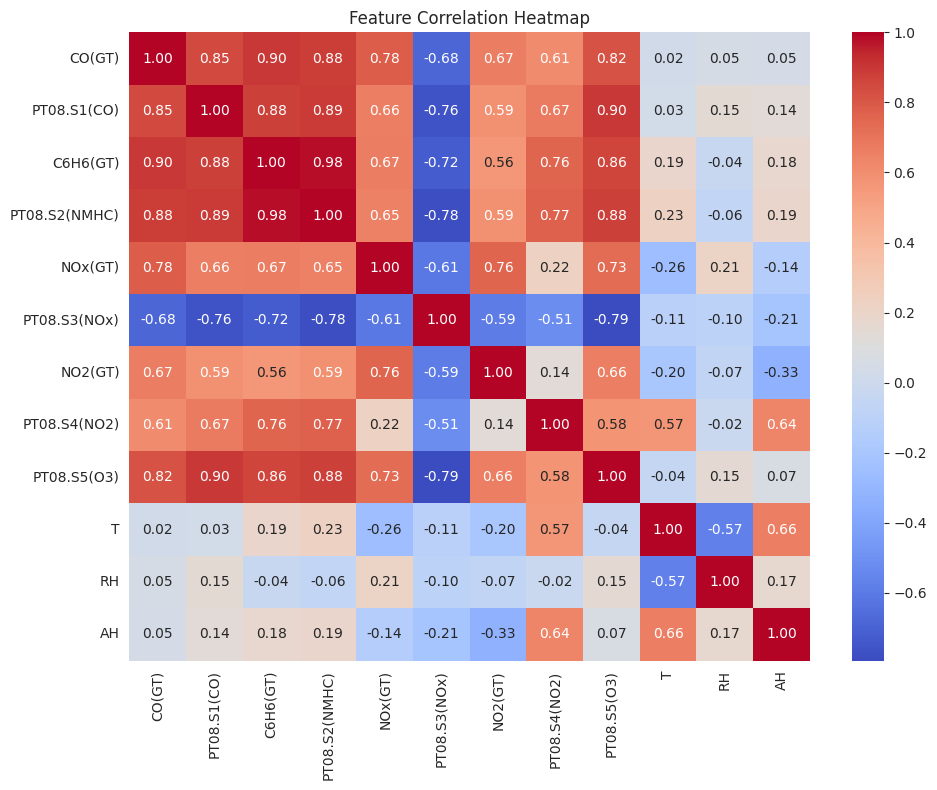

Train shape: (6139, 11) Test shape: (1535, 11)
[Linear Regression] RMSE=0.4814  MAE=0.3081  R2=0.8888  TrainTime=0.0531s


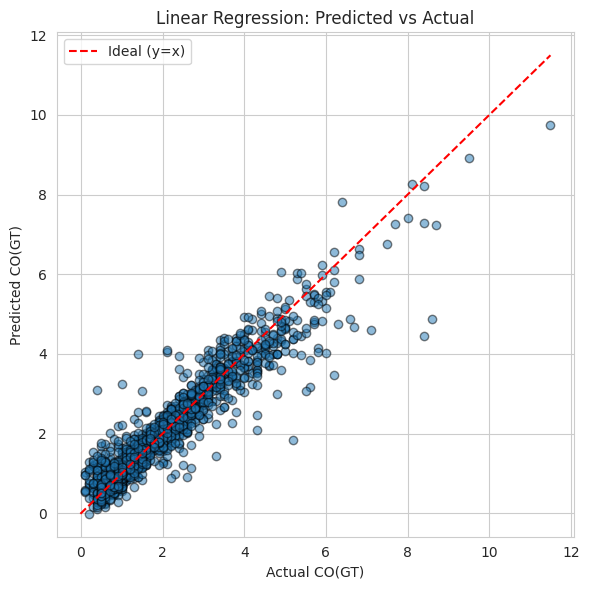

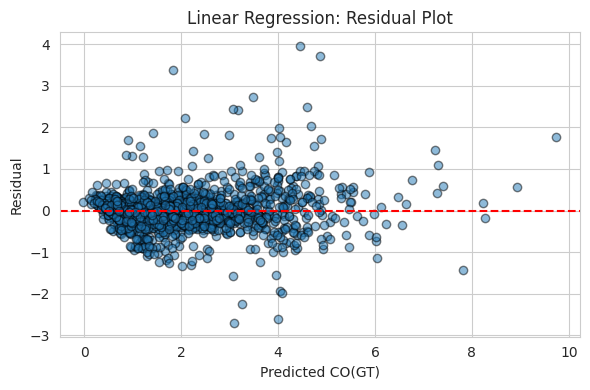

[GPR] RMSE=0.4292  MAE=0.2754  R2=0.9115  TrainTime=51.9155s  (trained on 800 samples)
Learned kernel: 4.1**2 * RBF(length_scale=6.54) + WhiteKernel(noise_level=0.175)


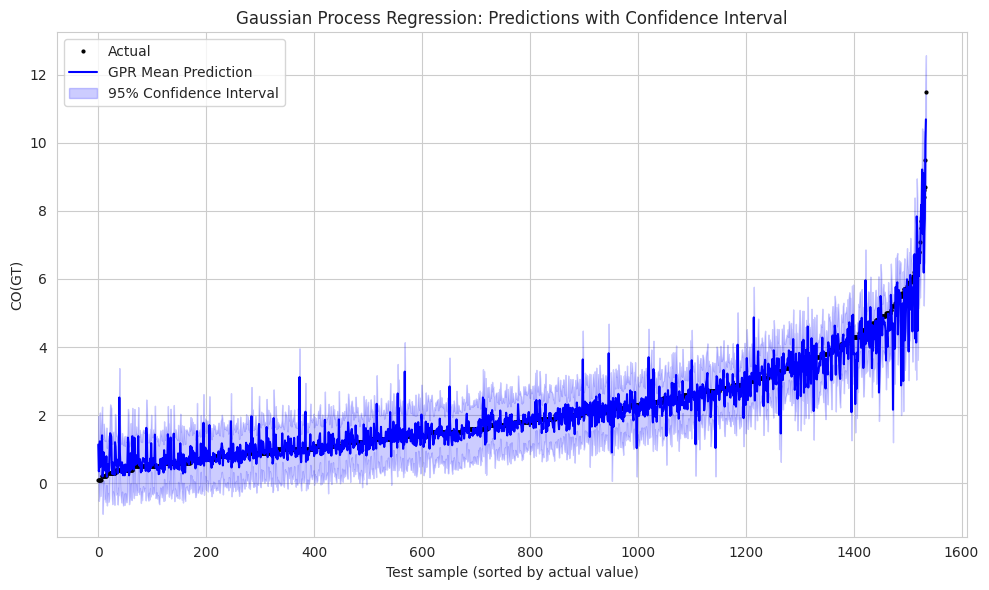

                         Model      RMSE       MAE        R2  \
0            Linear Regression  0.481369  0.308096  0.888752   
1  Gaussian Process Regression  0.429246  0.275400  0.911540   

   Training Time (s)  
0           0.053136  
1          51.915502  


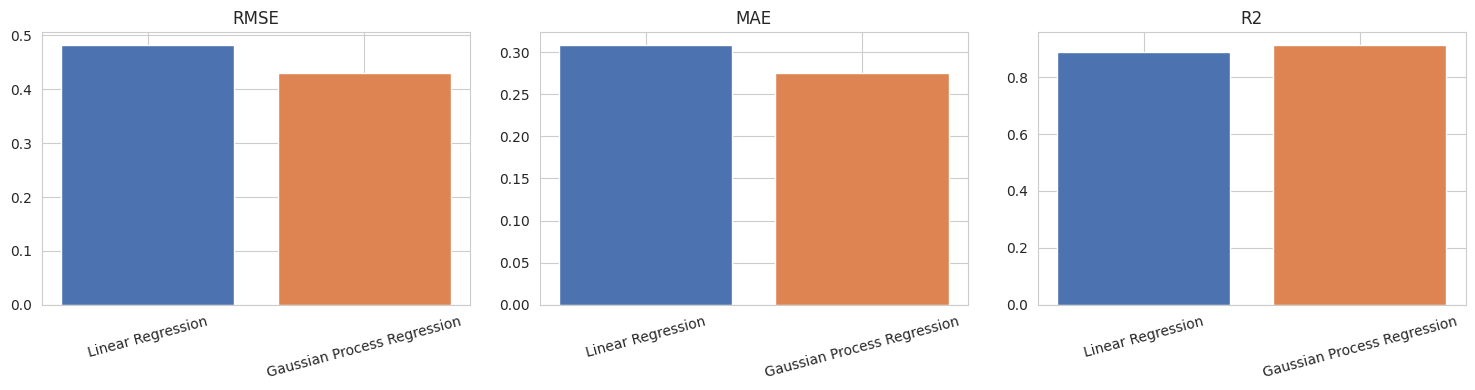


Example test point uncertainty (GPR only):
Actual: 7.100
GPR Predicted: 6.463 +/- 1.004 (95% CI)
LR Predicted: 4.602 (no uncertainty estimate available)

CONCLUSION (fill in after reviewing your actual results):
- Compare RMSE/MAE/R2 values above: which model fit better?
- Note training time difference (GPR is trained on a subsample and is
  still likely much slower per-sample than LR).
- GPR uniquely provides confidence intervals -- useful when downstream
  decisions need risk/uncertainty awareness (e.g. pollution alerts).
- State which model you'd recommend for this dataset and why.



In [ ]:
"""
CIA Component 2 - Linear Regression vs Gaussian Process Regression
Dataset: UCI Air Quality Dataset
https://archive.ics.uci.edu/dataset/360/air+quality

Run this as a script, or paste cells into a Jupyter Notebook
(recommended, since the assignment asks for a Jupyter Notebook deliverable).
Each "# %%" marks a natural cell boundary if you're using
VSCode/Jupyter's cell-mode, or just copy each section into its own
notebook cell.
"""

# %% [Section 0] -----------------------------------------------
import os
import io
import time
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
sns.set_style("whitegrid")

# %% [Section 1.1] Download & load the dataset
DATA_URL = "https://archive.ics.uci.edu/static/public/360/air+quality.zip"
DATA_DIR = "data"
CSV_PATH = os.path.join(DATA_DIR, "AirQualityUCI.csv")

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(CSV_PATH):
    print("Downloading UCI Air Quality dataset...")
    with urllib.request.urlopen(DATA_URL) as resp:
        zip_bytes = resp.read()
    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as z:
        z.extractall(DATA_DIR)
    print("Download complete.")
else:
    print("Dataset already present locally.")

# The raw file is semicolon-separated and uses commas as decimal points
df = pd.read_csv(CSV_PATH, sep=";", decimal=",")

print("Raw shape:", df.shape)
df.head()

# %% [Section 1.2] Drop junk columns -------------------------------------
# The CSV ships with two trailing empty/unnamed columns
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Drop rows that are entirely empty (trailing blank rows in the file)
df = df.dropna(how="all")

print("Shape after dropping junk columns/rows:", df.shape)
print(df.columns.tolist())

# %% [Section 1.3] Handle missing value code (-200) ----------------------
df = df.replace(-200, np.nan)

missing_pct = df.isna().mean().sort_values(ascending=False) * 100
print("Missing value percentage per column:\n", missing_pct)

# %% [Section 1.4] Basic description --------------------------------------
print(df.shape)
print(df.info())
print(df.describe())

# %% [Section 1.5] Choose target & feature set -----------------------------
TARGET = "CO(GT)"   # True hourly averaged CO concentration (mg/m^3)

# Drop rows where the target itself is missing
df = df.dropna(subset=[TARGET])

# Drop Date/Time (not used as numeric predictors here) and the NMHC(GT)
# column, which UCI documentation notes is mostly missing/unreliable
drop_cols = [c for c in ["Date", "Time", "NMHC(GT)"] if c in df.columns]
df_model = df.drop(columns=drop_cols)

# Impute remaining missing feature values with column median
df_model = df_model.fillna(df_model.median(numeric_only=True))

print("Final modelling shape:", df_model.shape)

# %% [Section 1.6] Correlation heatmap --------------------------------------
plt.figure(figsize=(10, 8))
sns.heatmap(df_model.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

# %% [Section 1.7] Train/test split & scaling --------------------------------
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, "Test shape:", X_test_scaled.shape)

# %% [Section 2] Linear Regression -------------------------------------------
lr_start = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_train_time = time.time() - lr_start

y_pred_lr = lr_model.predict(X_test_scaled)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print(f"[Linear Regression] RMSE={lr_rmse:.4f}  MAE={lr_mae:.4f}  R2={lr_r2:.4f}  "
      f"TrainTime={lr_train_time:.4f}s")

# Plot 1: Predicted vs Actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, edgecolor="k")
lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
plt.plot(lims, lims, "r--", label="Ideal (y=x)")
plt.xlabel("Actual CO(GT)")
plt.ylabel("Predicted CO(GT)")
plt.title("Linear Regression: Predicted vs Actual")
plt.legend()
plt.tight_layout()
plt.savefig("lr_pred_vs_actual.png", dpi=150)
plt.show()

# Plot 2: Residuals
residuals_lr = y_test - y_pred_lr
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_lr, residuals_lr, alpha=0.5, edgecolor="k")
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Predicted CO(GT)")
plt.ylabel("Residual")
plt.title("Linear Regression: Residual Plot")
plt.tight_layout()
plt.savefig("lr_residuals.png", dpi=150)
plt.show()

# %% [Section 3] Gaussian Process Regression ---------------------------------
# GPR scales as O(n^3) in training set size, so we subsample the training
# set to keep training tractable on a laptop.
GPR_SAMPLE_SIZE = 800
rng = np.random.RandomState(42)

if X_train_scaled.shape[0] > GPR_SAMPLE_SIZE:
    idx = rng.choice(X_train_scaled.shape[0], size=GPR_SAMPLE_SIZE, replace=False)
    X_train_gpr = X_train_scaled[idx]
    y_train_gpr = y_train.iloc[idx]
else:
    X_train_gpr = X_train_scaled
    y_train_gpr = y_train

# Kernel: RBF captures smooth nonlinear trends, WhiteKernel models
# observation noise (sensor noise is realistic here)
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) \
         + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))

gpr_start = time.time()
gpr_model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42)
gpr_model.fit(X_train_gpr, y_train_gpr)
gpr_train_time = time.time() - gpr_start

y_pred_gpr, y_std_gpr = gpr_model.predict(X_test_scaled, return_std=True)

gpr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gpr))
gpr_mae = mean_absolute_error(y_test, y_pred_gpr)
gpr_r2 = r2_score(y_test, y_pred_gpr)

print(f"[GPR] RMSE={gpr_rmse:.4f}  MAE={gpr_mae:.4f}  R2={gpr_r2:.4f}  "
      f"TrainTime={gpr_train_time:.4f}s  (trained on {GPR_SAMPLE_SIZE} samples)")
print("Learned kernel:", gpr_model.kernel_)

# Plot: predictions with 95% confidence interval, sorted for a clean curve
order = np.argsort(y_test.values)
y_test_sorted = y_test.values[order]
y_pred_sorted = y_pred_gpr[order]
y_std_sorted = y_std_gpr[order]
x_axis = np.arange(len(y_test_sorted))

plt.figure(figsize=(10, 6))
plt.plot(x_axis, y_test_sorted, "k.", markersize=4, label="Actual")
plt.plot(x_axis, y_pred_sorted, "b-", label="GPR Mean Prediction")
plt.fill_between(
    x_axis,
    y_pred_sorted - 1.96 * y_std_sorted,
    y_pred_sorted + 1.96 * y_std_sorted,
    color="blue", alpha=0.2, label="95% Confidence Interval"
)
plt.xlabel("Test sample (sorted by actual value)")
plt.ylabel("CO(GT)")
plt.title("Gaussian Process Regression: Predictions with Confidence Interval")
plt.legend()
plt.tight_layout()
plt.savefig("gpr_prediction_ci.png", dpi=150)
plt.show()

# %% [Section 4] Comparative Analysis ----------------------------------------
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Gaussian Process Regression"],
    "RMSE": [lr_rmse, gpr_rmse],
    "MAE": [lr_mae, gpr_mae],
    "R2": [lr_r2, gpr_r2],
    "Training Time (s)": [lr_train_time, gpr_train_time],
})
print(comparison)
comparison.to_csv("model_comparison.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics_to_plot = ["RMSE", "MAE", "R2"]
for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(comparison["Model"], comparison[metric], color=["#4C72B0", "#DD8452"])
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("metric_comparison_bars.png", dpi=150)
plt.show()

# Example: show an uncertainty comparison LR cannot provide
example_idx = 0
print(f"\nExample test point uncertainty (GPR only):")
print(f"Actual: {y_test.values[example_idx]:.3f}")
print(f"GPR Predicted: {y_pred_gpr[example_idx]:.3f} +/- {1.96*y_std_gpr[example_idx]:.3f} (95% CI)")
print(f"LR Predicted: {y_pred_lr[example_idx]:.3f} (no uncertainty estimate available)")

